In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['hatch.linewidth'] = 0.5

['/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf']


[(np.float64(0.5529411764705883), np.float64(0.8274509803921568), np.float64(0.7803921568627451), np.float64(1.0)), (np.float64(1.0), np.float64(1.0), np.float64(0.7019607843137254), np.float64(1.0)), (np.float64(0.7450980392156863), np.float64(0.7294117647058823), np.float64(0.8549019607843137), np.float64(1.0)), (np.float64(0.5019607843137255), np.float64(0.6941176470588235), np.float64(0.8274509803921568), np.float64(1.0)), (np.float64(0.9921568627450981), np.float64(0.7058823529411765), np.float64(0.3843137254901961), np.float64(1.0)), (np.float64(0.7019607843137254), np.float64(0.8705882352941177), np.float64(0.4117647058823529), np.float64(1.0)), (np.float64(0.8509803921568627), np.float64(0.8509803921568627), np.float64(0.8509803921568627), np.float64(1.0)), (np.float64(0.7372549019607844), np.float64(0.5019607843137255), np.float64(0.7411764705882353), np.float64(1.0)), (np.float64(0.8), np.float64(0.9215686274509803), np.float64(0.7725490196078432), np.float64(1.0)), (np.float

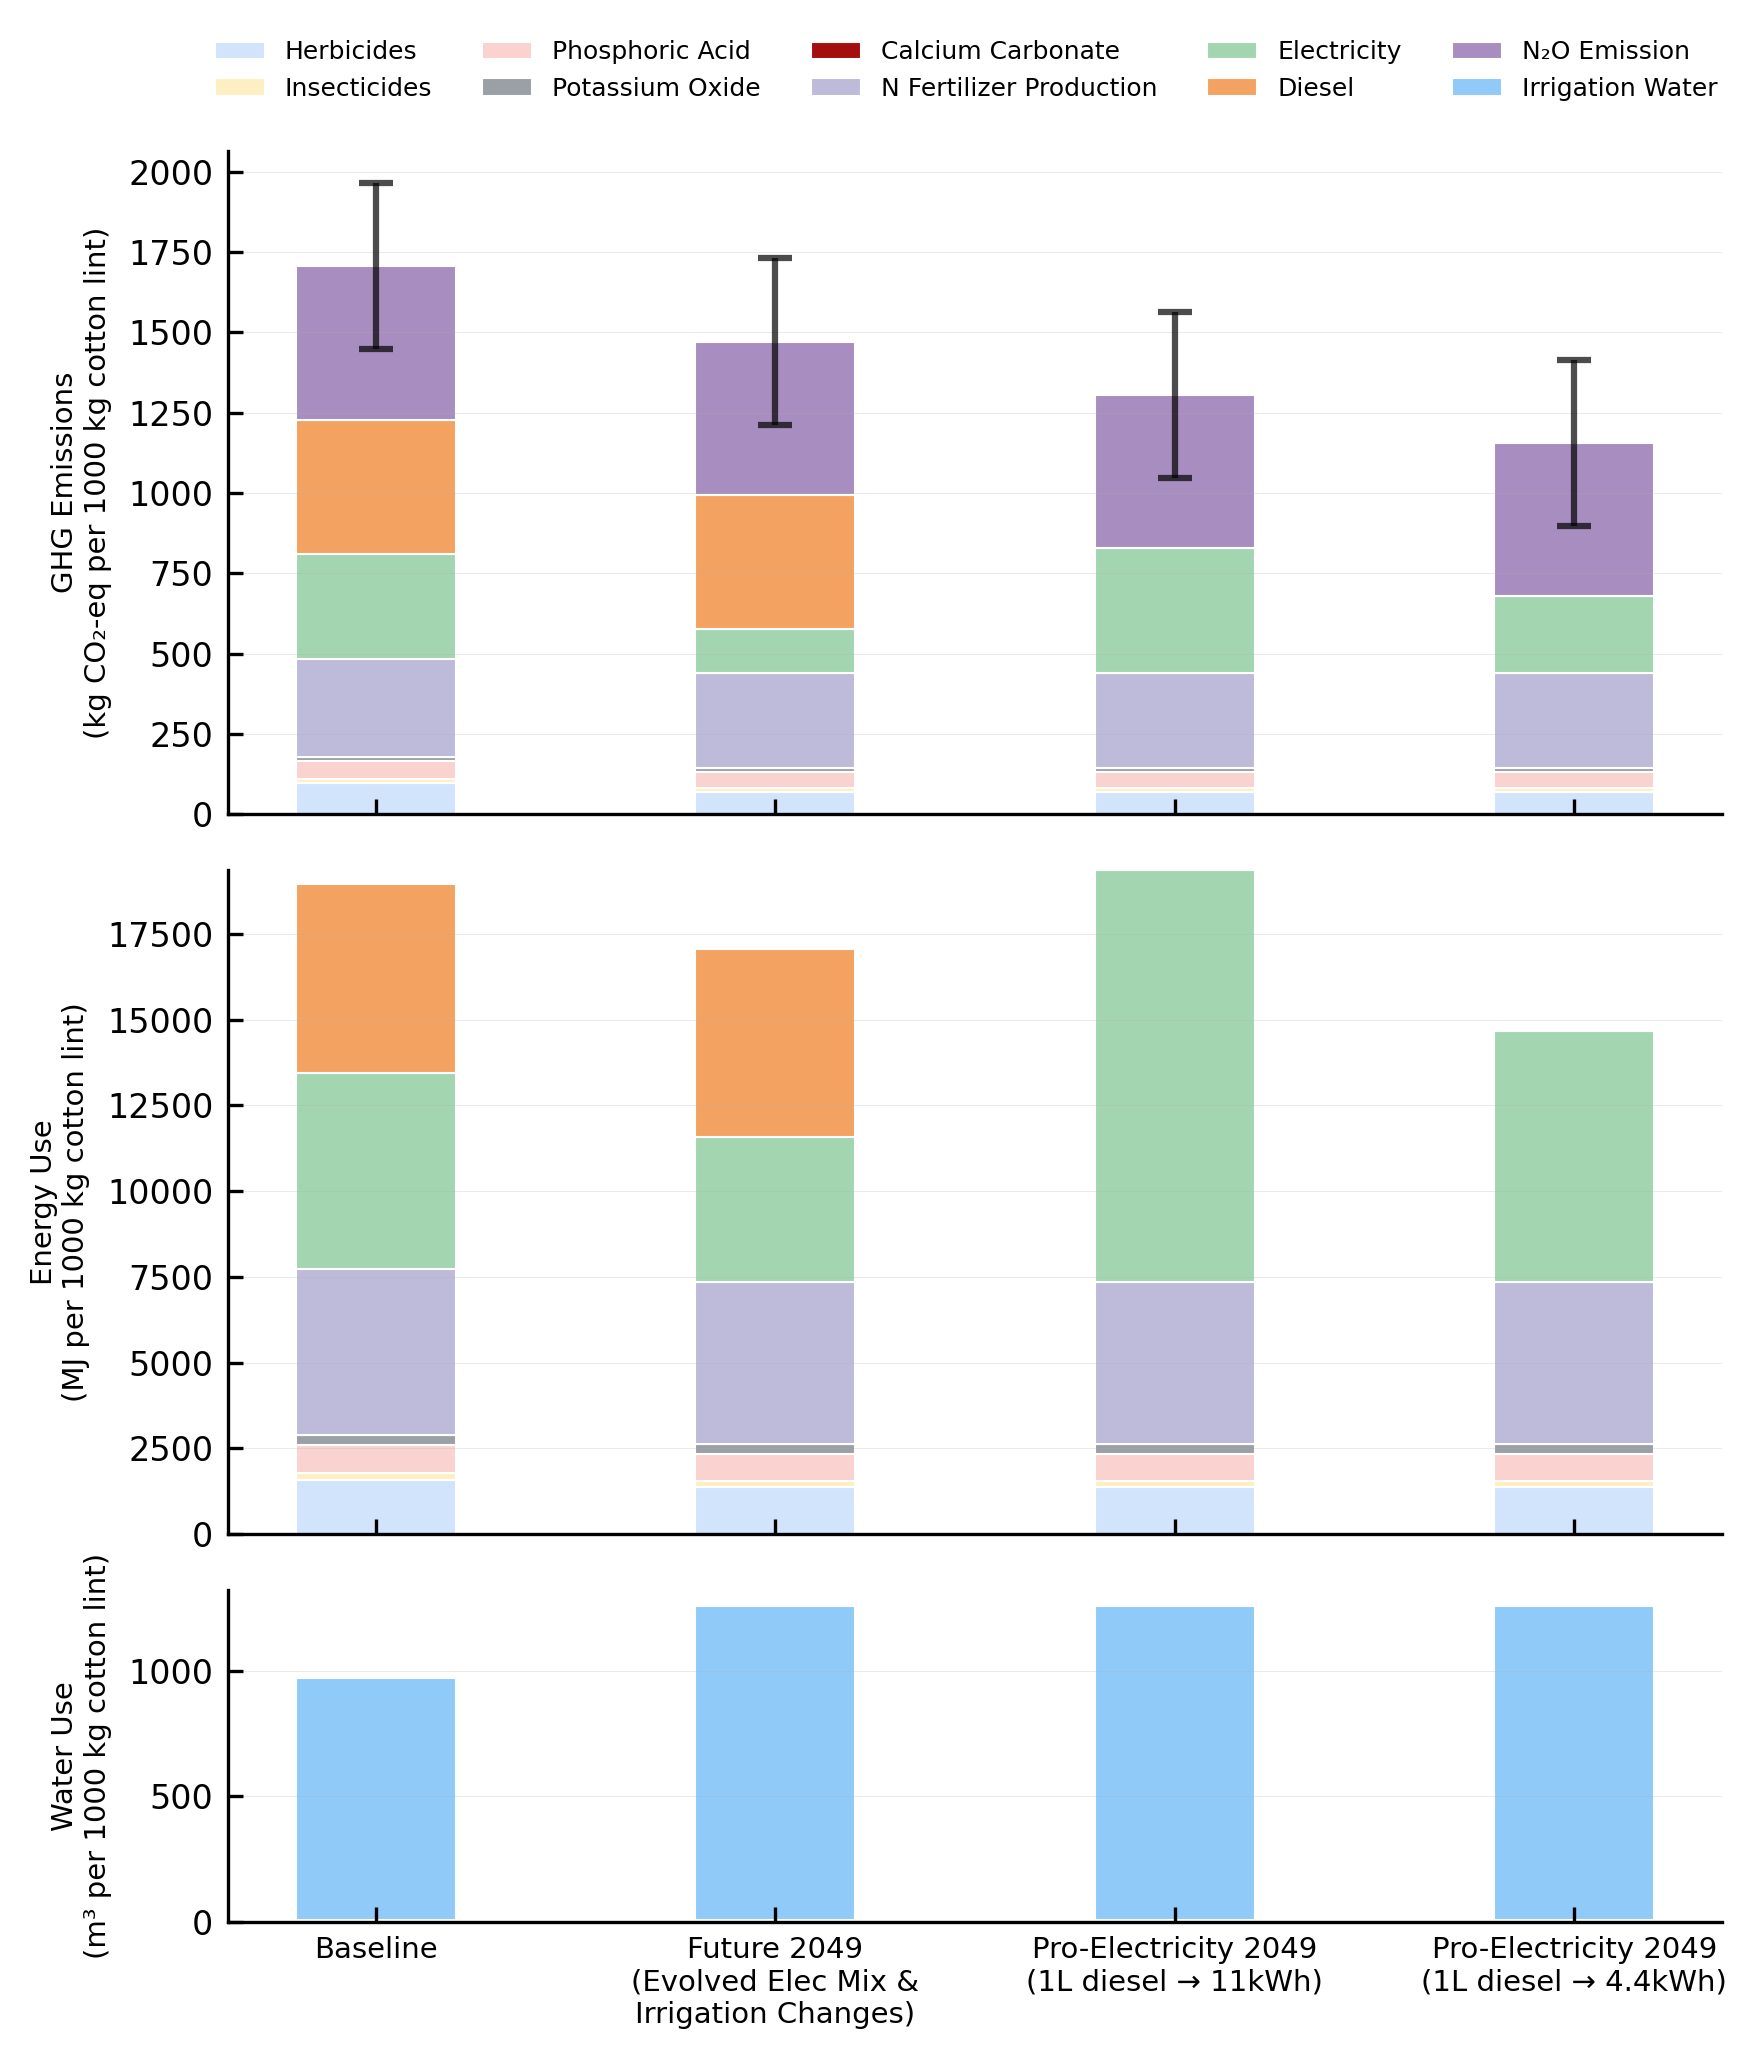

Summary Statistics (Per 1000 kg Cotton Lint):

N2O Emissions from Nitrogen Fertilizer:
Emission Factor Range: 0.8 - 2.7 kg N2O/1000kg cotton lint
Mean Emission Factor: 1.8 kg N2O/1000kg cotton lint
N2O GWP: 273 kg CO2-eq/kg N2O
N2O emissions per scenario: 477.8 ± 259.4 kg CO2-eq per 1000 kg cotton lint

Total GHG Emissions (kg CO₂-eq per 1000 kg cotton lint) - Including N2O:
Baseline: 1706.4 ± 259.4
  - Original GHG: 1228.7
  - N2O contribution: 477.8
Future 2049
(Evolved Elec Mix &
Irrigation Changes): 1470.4 ± 259.4
  - Original GHG: 992.6
  - N2O contribution: 477.8
Pro-Electricity 2049
(1L diesel → 11kWh): 1305.3 ± 259.4
  - Original GHG: 827.5
  - N2O contribution: 477.8
Pro-Electricity 2049
(1L diesel → 4.4kWh): 1156.0 ± 259.4
  - Original GHG: 678.2
  - N2O contribution: 477.8

Total Energy Use (MJ per 1000 kg cotton lint):
Baseline: 18954
Future 2049
(Evolved Elec Mix &
Irrigation Changes): 17077
Pro-Electricity 2049
(1L diesel → 11kWh): 19358
Pro-Electricity 2049
(1L diesel → 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Read the Excel file
df = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/lca_results for plot.xlsx', header=None)

# Define scenarios and their row positions with updated descriptive names
scenarios = [
    {'name': 'Baseline', 'start_row': 1},
    {'name': 'Future 2049\n(Evolved Elec Mix &\nIrrigation Changes)', 'start_row': 10},
    {'name': 'Pro-Electricity 2049\n(1L diesel → 11kWh)', 'start_row': 19},
    {'name': 'Pro-Electricity 2049\n(1L diesel → 4.4kWh)', 'start_row': 28}
]

# Categories for stacking (excluding total) - swapped nitrogen and electricity positions
categories = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
              'Calcium Carbonate', 'N Fertilizer Production', 'Electricity', 'Diesel']

# Categories for water (including irrigation water) - swapped nitrogen and electricity positions
water_categories = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
                   'Calcium Carbonate', 'N Fertilizer Production', 'Electricity', 'Diesel',
                   'Irrigation Water']

# N2O emission factors and GWP - now scaled for 1000 kg cotton lint
N2O_EF_MIN = 0.8  # kg N2O per 1000kg cotton lint (minimum)
N2O_EF_MAX = 2.7  # kg N2O per 1000kg cotton lint (maximum)
N2O_EF_MEAN = (N2O_EF_MIN + N2O_EF_MAX) / 2  # Mean emission factor
N2O_GWP = 273  # kg CO2-eq per kg N2O

# Initialize data storage
ghg_data = []
energy_data = []
water_data = []
n2o_emissions = []  # Store N2O emissions for each scenario
n2o_errors = []     # Store error ranges for N2O

# Scaling factor to convert from per kg to per 1000 kg
SCALE_FACTOR = 1000

# Extract data for each scenario
for scenario in scenarios:
    start_row = scenario['start_row']

    # GHG data (row start_row + 1, columns 2, 4, 6, 8, 10, 12, 14, 16)
    # Swapped order: columns 2, 4, 6, 8, 10, 14, 12, 16 (nitrogen before electricity)
    ghg_values = []
    column_order = [2, 4, 6, 8, 10, 14, 12, 16]  # Swapped columns 12 and 14
    for i in column_order:
        val = df.iloc[start_row + 1, i] if pd.notna(df.iloc[start_row + 1, i]) else 0
        # Convert units to kg for consistency and scale by 1000
        if i == 10:  # Calcium Carbonate is in mg
            val = val / 1000000 * SCALE_FACTOR  # mg to kg, then scale
        elif i in [2, 4, 6, 8]:  # These are in grams
            val = val / 1000 * SCALE_FACTOR  # g to kg, then scale
        else:  # Already in kg
            val = val * SCALE_FACTOR
        ghg_values.append(val)
    ghg_data.append(ghg_values)

    # Calculate N2O emissions from nitrogen fertilizer - now for 1000 kg cotton lint
    cotton_lint_kg = 1000.0  # Now calculating for 1000 kg
    n2o_emission_mean = N2O_EF_MEAN * N2O_GWP  # kg CO2-eq per 1000 kg cotton lint
    n2o_emission_min = N2O_EF_MIN * N2O_GWP
    n2o_emission_max = N2O_EF_MAX * N2O_GWP

    n2o_emissions.append(n2o_emission_mean)
    n2o_errors.append([n2o_emission_mean - n2o_emission_min, n2o_emission_max - n2o_emission_mean])

    # Energy data (row start_row + 3) - swapped order and scaled
    energy_values = []
    for i in column_order:
        val = df.iloc[start_row + 3, i] if pd.notna(df.iloc[start_row + 3, i]) else 0
        # Convert to MJ for consistency and scale by 1000
        if i == 10:  # Calcium Carbonate is in J
            val = val / 1000000 * SCALE_FACTOR  # J to MJ, then scale
        elif i in [2, 4, 6, 8, 12, 14, 16]:  # These are in kJ
            val = val / 1000 * SCALE_FACTOR  # kJ to MJ, then scale
        else:  # Already in MJ
            val = val * SCALE_FACTOR
        energy_values.append(val)
    energy_data.append(energy_values)

    # Water data (row start_row + 5) - including irrigation water, swapped order and scaled
    water_values = []
    water_column_order = [2, 4, 6, 8, 10, 14, 12, 16, 18]  # Added column 18 for irrigation water
    for i in water_column_order:
        val = df.iloc[start_row + 5, i] if pd.notna(df.iloc[start_row + 5, i]) else 0
        # Convert to m³ for consistency and scale by 1000
        if i in [2, 4, 6, 8, 10, 12, 14, 16]:  # These are in cm³
            val = val / 1000000 * SCALE_FACTOR  # cm³ to m³, then scale
        else:  # Column 18 (irrigation water) is already in m³
            val = val * SCALE_FACTOR
        water_values.append(val)
    water_data.append(water_values)

# Convert to numpy arrays for easier plotting
ghg_data = np.array(ghg_data).T
energy_data = np.array(energy_data).T
water_data = np.array(water_data).T
n2o_emissions = np.array(n2o_emissions)
n2o_errors = np.array(n2o_errors).T

# Create the plot with journal-appropriate styling
fig, axes = plt.subplots(3, 1, figsize=(7.2, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
# fig.suptitle('Environmental Impact Assessment of Cotton Production Scenarios',
#              fontsize=14, fontweight='bold', y=0.98)

# Professional color mapping for journal publication
def get_color_mapping():
    """Professional color scheme suitable for journal papers with clear distinction and accessibility"""
    color_map = {
        # Main contributors - distinct, saturated colors (swapped nitrogen and electricity)
        'Electricity': '#A4D5B1',
        'N Fertilizer Production': '#BEBADA',
        'N₂O Emission': '#A88EC0',
        'Diesel': '#F4A261',

        # Chemical inputs - muted professional colors
        'Herbicides': '#D2E3FC',            # Purple
        'Insecticides': '#FEEFC3',          # Red
        'Phosphoric Acid': '#FAD2CF',       # Brown
        'Potassium Oxide': '#9AA0A6',       # Blue grey
        'Calcium Carbonate': '#A50E0E',     # Grey

        # Water - blue theme
        'Irrigation Water': '#90CAF9'       # Water blue
    }
    return color_map
cmap = plt.get_cmap('Set3')
colors = [cmap(i) for i in np.linspace(0, 1, 10)]
print(colors)

# '#A4D5B1'
# '#A88EC0'
# '#F4A261'

color_mapping = get_color_mapping()

# Create color lists for plotting
colors = [color_mapping[cat] for cat in categories]
water_colors = [color_mapping[cat] for cat in water_categories]

# Scenario names for x-axis
scenario_names = [s['name'] for s in scenarios]
x_pos = np.arange(len(scenario_names))

# Set bar width (default is 0.8, reduce for narrower bars)
bar_width = 0.4  # Adjust this value: smaller = narrower bars

# Plot 1: GHG Emissions (including N2O from nitrogen)
bottom_ghg = np.zeros(len(scenario_names))
bars_ghg = []

# Plot original categories with refined styling
for i, (category, color) in enumerate(zip(categories, colors)):
    bars = axes[0].bar(x_pos, ghg_data[i], bottom=bottom_ghg, label=category,
                      color=color, alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
    bars_ghg.append(bars)
    bottom_ghg += ghg_data[i]

# Add N2O emissions as a separate category
n2o_bars = axes[0].bar(x_pos, n2o_emissions, bottom=bottom_ghg,
                       label='N₂O Emission', color=color_mapping['N₂O Emission'],
                       alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
bars_ghg.append(n2o_bars)

# Add error bars for total emissions (including N2O uncertainty)
total_ghg = np.sum(ghg_data, axis=0) + n2o_emissions
axes[0].errorbar(x_pos, total_ghg, yerr=n2o_errors, fmt='none', ecolor='black',
                capsize=4, capthick=1.5, linewidth=1.5, alpha=0.7)

# axes[0].set_title('(a) Greenhouse Gas Emissions', fontsize=12, fontweight='bold', pad=15)
axes[0].set_ylabel('GHG Emissions\n(kg CO₂-eq per 1000 kg cotton lint)', fontsize=7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(scenario_names, rotation=0, ha='center', fontsize=8)
axes[0].grid(axis='y', alpha=0.3, linewidth=0.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2: Energy Use
bottom_energy = np.zeros(len(scenario_names))
for i, (category, color) in enumerate(zip(categories, colors)):
    axes[1].bar(x_pos, energy_data[i], bottom=bottom_energy, color=color,
               alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
    bottom_energy += energy_data[i]

# axes[1].set_title('(b) Energy Consumption', fontsize=12, fontweight='bold', pad=15)
axes[1].set_ylabel('Energy Use\n(MJ per 1000 kg cotton lint)', fontsize=7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(scenario_names, rotation=0, ha='center', fontsize=8)
axes[1].grid(axis='y', alpha=0.3, linewidth=0.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Plot 3: Water Use (including irrigation water)
bottom_water = np.zeros(len(scenario_names))
for i, (category, color) in enumerate(zip(water_categories, water_colors)):
    axes[2].bar(x_pos, water_data[i], bottom=bottom_water, color=color,
               alpha=1, edgecolor='white', linewidth=0.5, width=bar_width)
    bottom_water += water_data[i]

# axes[2].set_title('(c) Water Consumption', fontsize=12, fontweight='bold', pad=15)
axes[2].set_ylabel('Water Use\n(m³ per 1000 kg cotton lint)', fontsize=7)
# axes[2].set_xlabel('Production Scenarios', fontsize=8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(scenario_names, rotation=0, ha='center', fontsize=7)
axes[2].grid(axis='y', alpha=0.3, linewidth=0.2)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

# Create a common legend for all subplots at the top
# Collect all unique categories across plots
all_categories = categories + ['N₂O Emission'] + ['Irrigation Water']
all_colors = [color_mapping[cat] for cat in all_categories]

# Create legend handles
legend_handles = [plt.Rectangle((0,0),1,1, facecolor=color, edgecolor='white', linewidth=0.5)
                 for color in all_colors]

# Position the common legend at the top of the figure
fig.legend(legend_handles, all_categories, loc='upper center', bbox_to_anchor=(0.45, 1.05),
          fontsize=6, frameon=False, fancybox=True, shadow=False, ncol=5)

# Adjust layout to prevent overlap
plt.tight_layout()

plt.subplots_adjust(right=0.8)  # Make room for legends
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_results.tiff', dpi=300, bbox_inches='tight')
# Display the plot
plt.show()

# Optional: Save the plot
# plt.savefig('lca_results_comparison_with_n2o_per_1000kg.png', dpi=300, bbox_inches='tight')

# Print summary statistics - updated for 1000 kg
print("Summary Statistics (Per 1000 kg Cotton Lint):")
print("\nN2O Emissions from Nitrogen Fertilizer:")
print(f"Emission Factor Range: {N2O_EF_MIN:.1f} - {N2O_EF_MAX:.1f} kg N2O/1000kg cotton lint")
print(f"Mean Emission Factor: {N2O_EF_MEAN:.1f} kg N2O/1000kg cotton lint")
print(f"N2O GWP: {N2O_GWP} kg CO2-eq/kg N2O")
print(f"N2O emissions per scenario: {n2o_emissions[0]:.1f} ± {(n2o_errors[1,0] + n2o_errors[0,0])/2:.1f} kg CO2-eq per 1000 kg cotton lint")

print("\nTotal GHG Emissions (kg CO₂-eq per 1000 kg cotton lint) - Including N2O:")
for i, scenario in enumerate(scenario_names):
    total_without_n2o = np.sum(ghg_data[:, i])
    total_with_n2o = total_without_n2o + n2o_emissions[i]
    error_range = n2o_errors[1,i] + n2o_errors[0,i]
    print(f"{scenario}: {total_with_n2o:.1f} ± {error_range/2:.1f}")
    print(f"  - Original GHG: {total_without_n2o:.1f}")
    print(f"  - N2O contribution: {n2o_emissions[i]:.1f}")

print("\nTotal Energy Use (MJ per 1000 kg cotton lint):")
for i, scenario in enumerate(scenario_names):
    print(f"{scenario}: {np.sum(energy_data[:, i]):.0f}")

print("\nTotal Water Use (m³ per 1000 kg cotton lint):")
for i, scenario in enumerate(scenario_names):
    print(f"{scenario}: {np.sum(water_data[:, i]):.1f}")

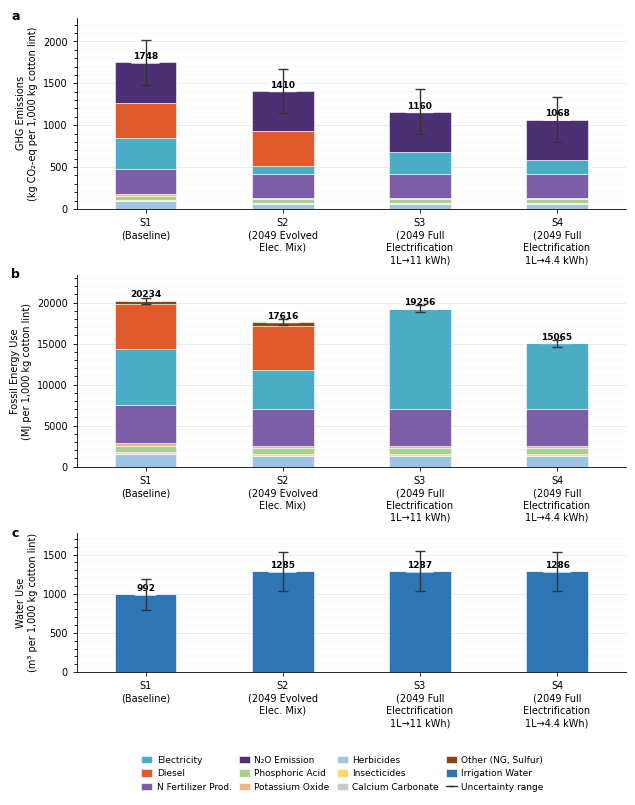

Metric                                     S1     S2     S3     S4
GHG total (kg CO₂-eq) [mid]              1748   1410   1160   1068
  of which N₂O                            478    478    478    478
  uncertainty ± (kg CO₂-eq)               266    263    269    269
Energy (MJ) [mid]                       20234  17616  19256  15065
Water (m³) [mid]                          992   1285   1287   1286


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings

# Turn off warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# VERIFIED DATA  (all values for 1,000 kg cotton lint functional unit)
# Source: Table 2, LCA Results sheet
# ─────────────────────────────────────────────────────────────────────────────

scenarios = ['S1\n(Baseline)', 'S2\n(2049 Evolved\nElec. Mix)',
             'S3\n(2049 Full\nElectrification\n1L→11 kWh)',
             'S4\n(2049 Full\nElectrification\n1L→4.4 kWh)']

# ── GHG [kg CO₂-eq] ──────────────────────────────────────────────────────────
# Stacked breakdown (midpoints for ranged values; N₂O added separately)
ghg = {
    'Herbicides':            np.array([92.99,  61.98,  61.98,  61.98]),
    'Insecticides':          np.array([14.35,  11.92,  11.92,  11.92]),
    'Phosphoric Acid':       np.array([52.09,  45.66,  45.66,  45.66]),
    'Potassium Oxide':       np.array([18.94,  12.46,  12.46,  12.46]),
    'Calcium Carbonate':     np.array([ 0.01,   0.01,   0.01,   0.01]),
    'N Fertilizer Prod.':    np.array([294.29, 282.01, 282.01, 282.01]),
    'Electricity':           np.array([311.17+(62.88+71.96)/2,
                                        84.09+(16.99+19.45)/2,
                                       238.09+(20.82+39.59)/2,
                                       145.69+(20.82+39.59)/2]),
    'Diesel':                np.array([415.41, 412.53,   0.00,   0.00]),
    'Other (NG, Sulfur)': np.array([(1.18+6.23)/2+0.21,
                                             (1.17+6.16)/2+0.09,
                                              0.00+0.09,
                                              0.00+0.09]),
}

N2O_GWP  = 273          # AR6 GWP100
N2O_MEAN = 1.75         # kg N₂O / 1000 kg lint
N2O_MIN  = 0.80
N2O_MAX  = 2.70
n2o_mean = N2O_MEAN * N2O_GWP   # 477.75 kg CO₂-eq
n2o_low  = N2O_MIN  * N2O_GWP   # 218.4
n2o_high = N2O_MAX  * N2O_GWP   # 737.1

# Total GHG (with N₂O) ± combined uncertainty (N₂O uncertainty dominates)
ghg_subtotal_low  = np.array([1263.54, 928.91, 673.05, 580.64])
ghg_subtotal_high = np.array([1277.67, 936.36, 691.82, 599.42])
ghg_subtotal_mid  = (ghg_subtotal_low + ghg_subtotal_high) / 2

total_ghg_mid  = ghg_subtotal_mid  + n2o_mean
err_ghg_low    = total_ghg_mid - (ghg_subtotal_low  + n2o_low)
err_ghg_high   = (ghg_subtotal_high + n2o_high) - total_ghg_mid
n2o_bar        = np.full(4, n2o_mean)

# ── Energy [MJ] ──────────────────────────────────────────────────────────────
eng = {
    'Herbicides':           np.array([1532.7, 1287.0, 1287.0, 1287.0]),
    'Insecticides':         np.array([ 213.5,  194.6,  194.6,  194.6]),
    'Phosphoric Acid':      np.array([ 774.0,  743.0,  743.0,  743.0]),
    'Potassium Oxide':      np.array([ 302.8,  251.5,  251.5,  251.5]),
    'Calcium Carbonate':    np.array([   0.2,    0.1,    0.1,    0.1]),
    'N Fertilizer Prod.':   np.array([4693.1, 4606.2, 4606.2, 4606.2]),
    # Field elec + ginning elec (mid)
    'Electricity':          np.array([5609.2+(1133.4+1297.2)/2,
                                      3814.5+(770.8+882.1)/2,
                                      10800.7+(194.2+369.4)/2*4.863,   # 2221 kWh×4.863 + ginning mid
                                       6609.0+(194.2+369.4)/2*4.863]), # 1359 kWh×4.863 + ginning mid
    'Diesel':               np.array([5485.2, 5485.2,    0.0,    0.0]),
    'Other (NG, Sulfur)': np.array([(129.2+680.2)/2+3.7,
                                             (129.2+680.2)/2+2.8,
                                              0.0+2.8, 0.0+2.8]),
}

eng_low  = np.array([19877.1, 17285.0, 18830.4, 14638.7])
eng_high = np.array([20591.9, 17947.4, 19682.2, 15490.4])
eng_mid  = (eng_low + eng_high) / 2
err_eng_low  = eng_mid - eng_low
err_eng_high = eng_high - eng_mid

# ── Water [m³] ───────────────────────────────────────────────────────────────
wat = {
    'Herbicides':           np.array([0.2371, 0.1535, 0.1535, 0.1535]),
    'Insecticides':         np.array([0.0250, 0.0184, 0.0184, 0.0184]),
    'Phosphoric Acid':      np.array([1.0203, 1.0029, 1.0029, 1.0029]),
    'Potassium Oxide':      np.array([0.1530, 0.1356, 0.1356, 0.1356]),
    'Calcium Carbonate':    np.array([0.0002, 0.0002, 0.0002, 0.0002]),
    'N Fertilizer Prod.':   np.array([1.3206, 1.2883, 1.2883, 1.2883]),
    'Electricity':          np.array([1.5140+(0.3059+0.3501)/2,
                                      0.9032+(0.1825+0.2089)/2,
                                      2.5575+(0.1825+0.2089)/2,
                                      1.5649+(0.1825+0.2089)/2]),
    'Diesel':               np.array([0.3815, 0.3695, 0.0000, 0.0000]),
    'Irrigation Water':     np.array([(792.1+1181.7)/2]*1 + [(1028.3+1534.1)/2]*3),
    'Other (NG, Sulfur)': np.array([(0.0014+0.0074)/2+0.0056,
                                             (0.0014+0.0073)/2+0.0053,
                                              0.0+0.0053, 0.0+0.0053]),
}

wat_low  = np.array([ 797.1, 1032.4, 1033.7, 1032.7])
wat_high = np.array([1186.7, 1538.2, 1539.7, 1538.7])
wat_mid  = (wat_low + wat_high) / 2
err_wat_low  = wat_mid - wat_low
err_wat_high = wat_high - wat_mid

# ─────────────────────────────────────────────────────────────────────────────
# COLOUR PALETTE  (Nature-style: colourblind-accessible, high contrast)
# ─────────────────────────────────────────────────────────────────────────────
palette = {
    'Herbicides':                '#9DC3E6',   # steel blue
    'Insecticides':              '#FFD966',   # amber
    'Phosphoric Acid':           '#A9D18E',   # sage green
    'Potassium Oxide':           '#F4B183',   # peach
    'Calcium Carbonate':         '#C9C9C9',   # light grey
    'N Fertilizer Prod.':        '#7B5EA7',   # purple
    'N₂O Emission':              '#4B3074',   # deep purple
    'Electricity':               '#4BACC6',   # teal
    'Diesel':                    '#E05A2B',   # burnt orange
    'Irrigation Water':          '#2E75B6',   # deep blue
    'Other (NG, Sulfur)':        '#8B4513',   # saddle brown
}

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE SETUP
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    # 'font.family':       'Arial',
    'font.size':         7,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.minor.size':  2,
    'ytick.minor.size':  2,
    'axes.labelsize':    7,
    'legend.fontsize':   6.5,
    'pdf.fonttype':      42,   # embed fonts for publisher
    'svg.fonttype':      'none',
})

fig = plt.figure(figsize=(7.08, 8.5))   # 180 mm wide (Nature 2-col)
gs  = GridSpec(3, 1, figure=fig, hspace=0.38,
               height_ratios=[2.2, 2.2, 1.6])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

x   = np.arange(4)
bw  = 0.45   # bar width

# ─────────────────────────────────────────────────────────────────────────────
# HELPER: draw stacked bars, return bottom array
# ─────────────────────────────────────────────────────────────────────────────
def stacked_bars(ax, data_dict, color_dict, x, bw, skip_keys=None):
    bottom = np.zeros(len(x))
    handles = {}
    for key, vals in data_dict.items():
        if skip_keys and key in skip_keys:
            continue
        bars = ax.bar(x, vals, bottom=bottom, width=bw,
                      color=color_dict[key], edgecolor='white',
                      linewidth=0.4, zorder=3)
        bottom += vals
        handles[key] = bars[0]
    return bottom, handles

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — GHG
# ─────────────────────────────────────────────────────────────────────────────
bottom_ghg, h_ghg = stacked_bars(ax1, ghg, palette, x, bw)

# N₂O on top
n2o_bars = ax1.bar(x, n2o_bar, bottom=bottom_ghg, width=bw,
                   color=palette['N₂O Emission'], edgecolor='white', linewidth=0.4, zorder=3)
h_ghg['N₂O Emission'] = n2o_bars[0]
bottom_ghg += n2o_bar

# Add mean value annotations just above the bars (below error bars)
for i, val in enumerate(total_ghg_mid):
    # Position text slightly above the bar top, with white background box for clarity
    ax1.text(i, total_ghg_mid[i] + 15, f'{val:.0f}',
             ha='center', va='bottom', fontsize=6.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

# Error bars (combined process + N₂O uncertainty)
ax1.errorbar(x, total_ghg_mid,
             yerr=[err_ghg_low, err_ghg_high],
             fmt='none', ecolor='#333333',
             capsize=3.5, capthick=1.0, linewidth=1.0, zorder=5)

ax1.set_ylabel('GHG Emissions\n(kg CO₂-eq per 1,000 kg cotton lint)', fontsize=7)
ax1.set_xlim(-0.5, 3.5)
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.08)
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios, fontsize=7, linespacing=1.3)
ax1.yaxis.set_minor_locator(plt.MultipleLocator(100))
ax1.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.4, zorder=0)
ax1.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.25, zorder=0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.text(-0.12, 1.04, 'a', transform=ax1.transAxes,
         fontsize=9, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Energy
# ─────────────────────────────────────────────────────────────────────────────
bottom_eng, h_eng = stacked_bars(ax2, eng, palette, x, bw)

# Add mean value annotations just above the bars (below error bars)
for i, val in enumerate(eng_mid):
    ax2.text(i, eng_mid[i] + 200, f'{val:.0f}',
             ha='center', va='bottom', fontsize=6.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

ax2.errorbar(x, eng_mid,
             yerr=[err_eng_low, err_eng_high],
             fmt='none', ecolor='#333333',
             capsize=3.5, capthick=1.0, linewidth=1.0, zorder=5)

ax2.set_ylabel('Fossil Energy Use\n(MJ per 1,000 kg cotton lint)', fontsize=7)
ax2.set_xlim(-0.5, 3.5)
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.08)
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios, fontsize=7, linespacing=1.3)
ax2.yaxis.set_minor_locator(plt.MultipleLocator(1000))
ax2.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.4, zorder=0)
ax2.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.25, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.text(-0.12, 1.04, 'b', transform=ax2.transAxes,
         fontsize=9, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — Water
# ─────────────────────────────────────────────────────────────────────────────
bottom_wat, h_wat = stacked_bars(ax3, wat, palette, x, bw)

# Add mean value annotations just above the bars (below error bars)
for i, val in enumerate(wat_mid):
    ax3.text(i, wat_mid[i] + 15, f'{val:.0f}',
             ha='center', va='bottom', fontsize=6.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8))

ax3.errorbar(x, wat_mid,
             yerr=[err_wat_low, err_wat_high],
             fmt='none', ecolor='#333333',
             capsize=3.5, capthick=1.0, linewidth=1.0, zorder=5)

ax3.set_ylabel('Water Use\n(m³ per 1,000 kg cotton lint)', fontsize=7)
ax3.set_xlim(-0.5, 3.5)
ax3.set_ylim(0, ax3.get_ylim()[1] * 1.10)
ax3.set_xticks(x)
ax3.set_xticklabels(scenarios, fontsize=7, linespacing=1.3)
ax3.yaxis.set_minor_locator(plt.MultipleLocator(100))
ax3.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.4, zorder=0)
ax3.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.25, zorder=0)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.text(-0.12, 1.04, 'c', transform=ax3.transAxes,
         fontsize=9, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────────
# UNIFIED LEGEND  (collected from all panels)
# ─────────────────────────────────────────────────────────────────────────────
legend_order = [
    'Electricity', 'Diesel', 'N Fertilizer Prod.', 'N₂O Emission',
    'Phosphoric Acid', 'Potassium Oxide', 'Herbicides', 'Insecticides',
    'Calcium Carbonate', 'Other (NG, Sulfur)', 'Irrigation Water'
]

all_handles = {**h_ghg, **h_eng, **h_wat}
legend_handles = [all_handles[k] for k in legend_order if k in all_handles]
legend_labels  = [k for k in legend_order if k in all_handles]

# Error-bar proxy for legend
from matplotlib.lines import Line2D
eb_proxy = Line2D([0], [0], color='#333333', linewidth=1.0,
                  marker='_', markersize=5, markeredgewidth=1.0)
legend_handles.append(eb_proxy)
legend_labels.append('Uncertainty range')

fig.legend(legend_handles, legend_labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04),
           ncol=4,
           fontsize=6.5,
           frameon=False,
           framealpha=0.9,
           edgecolor='#AAAAAA',
           handlelength=1.2,
           handleheight=0.9,
           columnspacing=0.8,
           handletextpad=0.5)

# ─────────────────────────────────────────────────────────────────────────────
# SAVE  (TIFF 600 dpi for Nature; also PNG for preview)
# ─────────────────────────────────────────────────────────────────────────────
fig.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_results_nature.tiff',
            dpi=300, bbox_inches='tight', format='tiff')
# fig.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_results_nature.pdf',
#             bbox_inches='tight', format='pdf')  # vector for submission
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 65)
print(f"{'Metric':<38}  {'S1':>5}  {'S2':>5}  {'S3':>5}  {'S4':>5}")
print("=" * 65)
print(f"{'GHG total (kg CO₂-eq) [mid]':<38}  "
      + "  ".join(f"{v:5.0f}" for v in total_ghg_mid))
print(f"{'  of which N₂O':<38}  " + "  ".join([f"{n2o_mean:5.0f}"]*4))
print(f"{'  uncertainty ± (kg CO₂-eq)':<38}  "
      + "  ".join(f"{(a+b)/2:5.0f}" for a,b in zip(err_ghg_low, err_ghg_high)))
print(f"{'Energy (MJ) [mid]':<38}  "
      + "  ".join(f"{v:5.0f}" for v in eng_mid))
print(f"{'Water (m³) [mid]':<38}  "
      + "  ".join(f"{v:5.0f}" for v in wat_mid))
print("=" * 65)

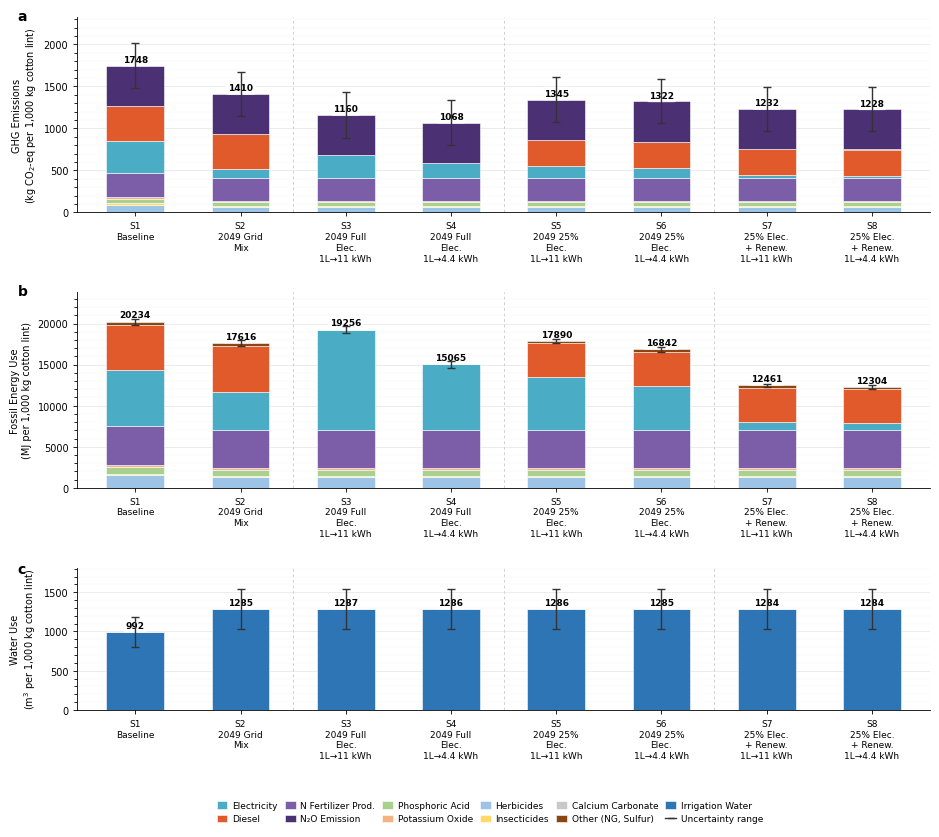

Metric                                 S1       S2       S3       S4       S5       S6       S7       S8
GHG total (kg CO2-eq) [mid]          1748     1410     1160     1068     1345     1322     1232     1228
   of which N2O                       478      478      478      478      478      478      478      478
   uncertainty ±                      266      263      269      269      262      262      261      261
Energy (MJ) [mid]                   20234    17616    19256    15065    17890    16842    12461    12304
   uncertainty ±                      357      331      426      426      262      262      215      215
Water (m3) [mid]                      992     1285     1287     1286     1286     1285     1284     1284
   uncertainty ±                      195      253      253      253      253      253      253      253

GHG reduction vs S1 baseline (%):
  S1:  +0.0%  S2: +19.3%  S3: +33.6%  S4: +38.9%  S5: +23.1%  S6: +24.4%  S7: +29.5%  S8: +29.8%


In [3]:
"""
LCA results figure — 8 scenarios for cotton lint (per 1,000 kg).

Scenarios
---------
S1  Baseline (present-day)
S2  2049 evolved electricity mix (no field electrification)
S3  2049 full field electrification, 1 L diesel → 11.0 kWh
S4  2049 full field electrification, 1 L diesel → 4.4 kWh
S5  2049 25 % field electrification, 1 L diesel → 11.0 kWh   (NEW)
S6  2049 25 % field electrification, 1 L diesel → 4.4 kWh    (NEW)
S7  2049 25 % electrification + renewable (solar/wind), 1L → 11 kWh   (NEW)
S8  2049 25 % electrification + renewable (solar/wind), 1L → 4.4 kWh  (NEW)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ═════════════════════════════════════════════════════════════════════════════
# USER-ADJUSTABLE ASSUMPTIONS  (tweak these to match your inventory data)
# ═════════════════════════════════════════════════════════════════════════════
PARTIAL_ELEC_FRAC  = 0.25                   # fraction of diesel electrified (S5–S8)
DIESEL_REMAIN_FRAC = 1 - PARTIAL_ELEC_FRAC  # 0.75

# Renewable electricity impact factors RELATIVE to the 2049 evolved grid mix.
# Based on IPCC AR6 lifecycle data:
#   Solar PV utility ~45 g CO2-eq/kWh, Wind onshore ~12 g CO2-eq/kWh
#   2049 evolved grid (mostly low-carbon mix) ~100–150 g CO2-eq/kWh
# Adjust if your inventory implies different ratios.
REN_GHG_FACTOR = 0.20   # 80 % reduction vs evolved grid
REN_ENG_FACTOR = 0.15   # very low fossil-energy demand
REN_WAT_FACTOR = 0.10   # very low operational water demand

# ═════════════════════════════════════════════════════════════════════════════
# SCENARIO LABELS  (multi-line for compact x-axis)
# ═════════════════════════════════════════════════════════════════════════════
scenarios = [
    'S1\nBaseline',
    'S2\n2049 Grid\nMix',
    'S3\n2049 Full\nElec.\n1L→11 kWh',
    'S4\n2049 Full\nElec.\n1L→4.4 kWh',
    'S5\n2049 25%\nElec.\n1L→11 kWh',
    'S6\n2049 25%\nElec.\n1L→4.4 kWh',
    'S7\n25% Elec.\n+ Renew.\n1L→11 kWh',
    'S8\n25% Elec.\n+ Renew.\n1L→4.4 kWh',
]
n_sc = len(scenarios)

# ═════════════════════════════════════════════════════════════════════════════
# PRE-COMPUTED INTERMEDIATE VALUES  (used for S5–S8)
# ═════════════════════════════════════════════════════════════════════════════
# ── GHG (kg CO₂-eq) ──────────────────────────────────────────────────────────
S2_FIELD_ELEC_GHG    = 84.09
S2_GIN_ELEC_GHG_LOW  = 16.99
S2_GIN_ELEC_GHG_HIGH = 19.45
EXTRA_ELEC_GHG_11    = 238.09 - 84.09      # 154.00  (full conversion @ 11 kWh/L)
EXTRA_ELEC_GHG_44    = 145.69 - 84.09      # 61.60   (full conversion @ 4.4 kWh/L)
S5_FIELD_ELEC_GHG    = S2_FIELD_ELEC_GHG + PARTIAL_ELEC_FRAC * EXTRA_ELEC_GHG_11
S6_FIELD_ELEC_GHG    = S2_FIELD_ELEC_GHG + PARTIAL_ELEC_FRAC * EXTRA_ELEC_GHG_44

# ── Energy (MJ) ──────────────────────────────────────────────────────────────
S2_FIELD_ELEC_ENG    = 3814.5
S2_GIN_ELEC_ENG_LOW  = 770.8
S2_GIN_ELEC_ENG_HIGH = 882.1
EXTRA_ELEC_ENG_11    = 10800.7 - 3814.5    # 6986.2
EXTRA_ELEC_ENG_44    = 6609.0  - 3814.5    # 2794.5
S5_FIELD_ELEC_ENG    = S2_FIELD_ELEC_ENG + PARTIAL_ELEC_FRAC * EXTRA_ELEC_ENG_11
S6_FIELD_ELEC_ENG    = S2_FIELD_ELEC_ENG + PARTIAL_ELEC_FRAC * EXTRA_ELEC_ENG_44

# ── Water (m³) ───────────────────────────────────────────────────────────────
S2_FIELD_ELEC_WAT    = 0.9032
S2_GIN_ELEC_WAT_LOW  = 0.1825
S2_GIN_ELEC_WAT_HIGH = 0.2089
EXTRA_ELEC_WAT_11    = 2.5575 - 0.9032     # 1.6543
EXTRA_ELEC_WAT_44    = 1.5649 - 0.9032     # 0.6617
S5_FIELD_ELEC_WAT    = S2_FIELD_ELEC_WAT + PARTIAL_ELEC_FRAC * EXTRA_ELEC_WAT_11
S6_FIELD_ELEC_WAT    = S2_FIELD_ELEC_WAT + PARTIAL_ELEC_FRAC * EXTRA_ELEC_WAT_44

# Helper for ginning-electricity mid value
mid = lambda lo, hi: 0.5 * (lo + hi)

# ═════════════════════════════════════════════════════════════════════════════
# DATA — GHG (kg CO₂-eq / 1,000 kg lint)        [mid values shown]
# ═════════════════════════════════════════════════════════════════════════════
ghg = {
    'Herbicides'         : np.array([92.99, 61.98, 61.98, 61.98, 61.98, 61.98, 61.98, 61.98]),
    'Insecticides'       : np.array([14.35, 11.92, 11.92, 11.92, 11.92, 11.92, 11.92, 11.92]),
    'Phosphoric Acid'    : np.array([52.09, 45.66, 45.66, 45.66, 45.66, 45.66, 45.66, 45.66]),
    'Potassium Oxide'    : np.array([18.94, 12.46, 12.46, 12.46, 12.46, 12.46, 12.46, 12.46]),
    'Calcium Carbonate'  : np.array([ 0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01,  0.01]),
    'N Fertilizer Prod.' : np.array([294.29, 282.01, 282.01, 282.01, 282.01, 282.01, 282.01, 282.01]),
    'Electricity'        : np.array([
        311.17 + mid(62.88, 71.96),                                                 # S1
        84.09  + mid(16.99, 19.45),                                                 # S2
        238.09 + mid(20.82, 39.59),                                                 # S3
        145.69 + mid(20.82, 39.59),                                                 # S4
        S5_FIELD_ELEC_GHG + mid(S2_GIN_ELEC_GHG_LOW,  S2_GIN_ELEC_GHG_HIGH),        # S5
        S6_FIELD_ELEC_GHG + mid(S2_GIN_ELEC_GHG_LOW,  S2_GIN_ELEC_GHG_HIGH),        # S6
       (S5_FIELD_ELEC_GHG + mid(S2_GIN_ELEC_GHG_LOW,  S2_GIN_ELEC_GHG_HIGH)) * REN_GHG_FACTOR,  # S7
       (S6_FIELD_ELEC_GHG + mid(S2_GIN_ELEC_GHG_LOW,  S2_GIN_ELEC_GHG_HIGH)) * REN_GHG_FACTOR,  # S8
    ]),
    'Diesel'             : np.array([
        415.41, 412.53, 0.00, 0.00,
        412.53 * DIESEL_REMAIN_FRAC,      # S5
        412.53 * DIESEL_REMAIN_FRAC,      # S6
        412.53 * DIESEL_REMAIN_FRAC,      # S7
        412.53 * DIESEL_REMAIN_FRAC,      # S8
    ]),
    'Other (NG, Sulfur)' : np.array([
        mid(1.18, 6.23) + 0.21,                                       # S1
        mid(1.17, 6.16) + 0.09,                                       # S2
        0.00            + 0.09,                                       # S3
        0.00            + 0.09,                                       # S4
        mid(1.17, 6.16) * DIESEL_REMAIN_FRAC + 0.09,                  # S5
        mid(1.17, 6.16) * DIESEL_REMAIN_FRAC + 0.09,                  # S6
        mid(1.17, 6.16) * DIESEL_REMAIN_FRAC + 0.09,                  # S7
        mid(1.17, 6.16) * DIESEL_REMAIN_FRAC + 0.09,                  # S8
    ]),
}

# ── GHG uncertainty bounds (process only, excludes N₂O) ──────────────────────
# Compute low/high totals analytically: fixed comp + NG-range + ginning-range
def fixed_sum_ghg(i):
    """Sum of non-uncertain components + field electricity for scenario i."""
    keys = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
            'Calcium Carbonate', 'N Fertilizer Prod.', 'Diesel']
    field_elec_ghg = np.array([311.17, 84.09, 238.09, 145.69,
                                S5_FIELD_ELEC_GHG, S6_FIELD_ELEC_GHG,
                                S5_FIELD_ELEC_GHG * REN_GHG_FACTOR,
                                S6_FIELD_ELEC_GHG * REN_GHG_FACTOR])
    return sum(ghg[k][i] for k in keys) + field_elec_ghg[i]

# NG low/high per scenario
ng_ghg_low  = np.array([1.18, 1.17, 0.00, 0.00,
                         1.17 * DIESEL_REMAIN_FRAC, 1.17 * DIESEL_REMAIN_FRAC,
                         1.17 * DIESEL_REMAIN_FRAC, 1.17 * DIESEL_REMAIN_FRAC])
ng_ghg_high = np.array([6.23, 6.16, 0.00, 0.00,
                         6.16 * DIESEL_REMAIN_FRAC, 6.16 * DIESEL_REMAIN_FRAC,
                         6.16 * DIESEL_REMAIN_FRAC, 6.16 * DIESEL_REMAIN_FRAC])
sulfur_ghg  = np.array([0.21, 0.09, 0.09, 0.09, 0.09, 0.09, 0.09, 0.09])

# Ginning-electricity low/high per scenario
gin_ghg_low  = np.array([62.88, 16.99, 20.82, 20.82,
                          S2_GIN_ELEC_GHG_LOW,  S2_GIN_ELEC_GHG_LOW,
                          S2_GIN_ELEC_GHG_LOW  * REN_GHG_FACTOR,
                          S2_GIN_ELEC_GHG_LOW  * REN_GHG_FACTOR])
gin_ghg_high = np.array([71.96, 19.45, 39.59, 39.59,
                          S2_GIN_ELEC_GHG_HIGH, S2_GIN_ELEC_GHG_HIGH,
                          S2_GIN_ELEC_GHG_HIGH * REN_GHG_FACTOR,
                          S2_GIN_ELEC_GHG_HIGH * REN_GHG_FACTOR])

ghg_subtotal_low  = np.array([fixed_sum_ghg(i) for i in range(n_sc)]) + ng_ghg_low  + sulfur_ghg + gin_ghg_low
ghg_subtotal_high = np.array([fixed_sum_ghg(i) for i in range(n_sc)]) + ng_ghg_high + sulfur_ghg + gin_ghg_high
ghg_subtotal_mid  = 0.5 * (ghg_subtotal_low + ghg_subtotal_high)

# ── N₂O field emissions (same for all scenarios) ─────────────────────────────
N2O_GWP  = 273       # AR6 GWP100
N2O_MEAN, N2O_MIN, N2O_MAX = 1.75, 0.80, 2.70   # kg N₂O / 1,000 kg lint
n2o_mean = N2O_MEAN * N2O_GWP    # 477.75
n2o_low  = N2O_MIN  * N2O_GWP    # 218.4
n2o_high = N2O_MAX  * N2O_GWP    # 737.1

total_ghg_mid = ghg_subtotal_mid + n2o_mean
err_ghg_low   = total_ghg_mid - (ghg_subtotal_low  + n2o_low)
err_ghg_high  = (ghg_subtotal_high + n2o_high) - total_ghg_mid
n2o_bar       = np.full(n_sc, n2o_mean)

# ═════════════════════════════════════════════════════════════════════════════
# DATA — ENERGY (MJ / 1,000 kg lint)
# ═════════════════════════════════════════════════════════════════════════════
eng = {
    'Herbicides'         : np.array([1532.7, 1287.0, 1287.0, 1287.0, 1287.0, 1287.0, 1287.0, 1287.0]),
    'Insecticides'       : np.array([ 213.5,  194.6,  194.6,  194.6,  194.6,  194.6,  194.6,  194.6]),
    'Phosphoric Acid'    : np.array([ 774.0,  743.0,  743.0,  743.0,  743.0,  743.0,  743.0,  743.0]),
    'Potassium Oxide'    : np.array([ 302.8,  251.5,  251.5,  251.5,  251.5,  251.5,  251.5,  251.5]),
    'Calcium Carbonate'  : np.array([   0.2,    0.1,    0.1,    0.1,    0.1,    0.1,    0.1,    0.1]),
    'N Fertilizer Prod.' : np.array([4693.1, 4606.2, 4606.2, 4606.2, 4606.2, 4606.2, 4606.2, 4606.2]),
    'Electricity'        : np.array([
        5609.2  + mid(1133.4, 1297.2),                                                       # S1
        3814.5  + mid( 770.8,  882.1),                                                       # S2
        10800.7 + mid(194.2, 369.4) * 4.863,                                                  # S3
         6609.0 + mid(194.2, 369.4) * 4.863,                                                  # S4
        S5_FIELD_ELEC_ENG + mid(S2_GIN_ELEC_ENG_LOW,  S2_GIN_ELEC_ENG_HIGH),                  # S5
        S6_FIELD_ELEC_ENG + mid(S2_GIN_ELEC_ENG_LOW,  S2_GIN_ELEC_ENG_HIGH),                  # S6
       (S5_FIELD_ELEC_ENG + mid(S2_GIN_ELEC_ENG_LOW,  S2_GIN_ELEC_ENG_HIGH)) * REN_ENG_FACTOR, # S7
       (S6_FIELD_ELEC_ENG + mid(S2_GIN_ELEC_ENG_LOW,  S2_GIN_ELEC_ENG_HIGH)) * REN_ENG_FACTOR, # S8
    ]),
    'Diesel'             : np.array([
        5485.2, 5485.2, 0.0, 0.0,
        5485.2 * DIESEL_REMAIN_FRAC,
        5485.2 * DIESEL_REMAIN_FRAC,
        5485.2 * DIESEL_REMAIN_FRAC,
        5485.2 * DIESEL_REMAIN_FRAC,
    ]),
    'Other (NG, Sulfur)' : np.array([
        mid(129.2, 680.2) + 3.7,
        mid(129.2, 680.2) + 2.8,
        0.0               + 2.8,
        0.0               + 2.8,
        mid(129.2, 680.2) * DIESEL_REMAIN_FRAC + 2.8,
        mid(129.2, 680.2) * DIESEL_REMAIN_FRAC + 2.8,
        mid(129.2, 680.2) * DIESEL_REMAIN_FRAC + 2.8,
        mid(129.2, 680.2) * DIESEL_REMAIN_FRAC + 2.8,
    ]),
}

# ── Energy bounds ────────────────────────────────────────────────────────────
def fixed_sum_eng(i):
    keys = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
            'Calcium Carbonate', 'N Fertilizer Prod.', 'Diesel']
    field_elec_eng = np.array([5609.2, 3814.5, 10800.7, 6609.0,
                                S5_FIELD_ELEC_ENG, S6_FIELD_ELEC_ENG,
                                S5_FIELD_ELEC_ENG * REN_ENG_FACTOR,
                                S6_FIELD_ELEC_ENG * REN_ENG_FACTOR])
    return sum(eng[k][i] for k in keys) + field_elec_eng[i]

ng_eng_low   = np.array([129.2, 129.2, 0.0, 0.0,
                          129.2 * DIESEL_REMAIN_FRAC, 129.2 * DIESEL_REMAIN_FRAC,
                          129.2 * DIESEL_REMAIN_FRAC, 129.2 * DIESEL_REMAIN_FRAC])
ng_eng_high  = np.array([680.2, 680.2, 0.0, 0.0,
                          680.2 * DIESEL_REMAIN_FRAC, 680.2 * DIESEL_REMAIN_FRAC,
                          680.2 * DIESEL_REMAIN_FRAC, 680.2 * DIESEL_REMAIN_FRAC])
sulfur_eng   = np.array([3.7, 2.8, 2.8, 2.8, 2.8, 2.8, 2.8, 2.8])

# Ginning energy bounds (S3/S4 use the *4.863 kWh→MJ form)
gin_eng_low  = np.array([1133.4, 770.8, 194.2 * 4.863, 194.2 * 4.863,
                          S2_GIN_ELEC_ENG_LOW,  S2_GIN_ELEC_ENG_LOW,
                          S2_GIN_ELEC_ENG_LOW  * REN_ENG_FACTOR,
                          S2_GIN_ELEC_ENG_LOW  * REN_ENG_FACTOR])
gin_eng_high = np.array([1297.2, 882.1, 369.4 * 4.863, 369.4 * 4.863,
                          S2_GIN_ELEC_ENG_HIGH, S2_GIN_ELEC_ENG_HIGH,
                          S2_GIN_ELEC_ENG_HIGH * REN_ENG_FACTOR,
                          S2_GIN_ELEC_ENG_HIGH * REN_ENG_FACTOR])

eng_low  = np.array([fixed_sum_eng(i) for i in range(n_sc)]) + ng_eng_low  + sulfur_eng + gin_eng_low
eng_high = np.array([fixed_sum_eng(i) for i in range(n_sc)]) + ng_eng_high + sulfur_eng + gin_eng_high
eng_mid  = 0.5 * (eng_low + eng_high)
err_eng_low  = eng_mid - eng_low
err_eng_high = eng_high - eng_mid

# ═════════════════════════════════════════════════════════════════════════════
# DATA — WATER (m³ / 1,000 kg lint)
# ═════════════════════════════════════════════════════════════════════════════
wat = {
    'Herbicides'         : np.array([0.2371, 0.1535, 0.1535, 0.1535, 0.1535, 0.1535, 0.1535, 0.1535]),
    'Insecticides'       : np.array([0.0250, 0.0184, 0.0184, 0.0184, 0.0184, 0.0184, 0.0184, 0.0184]),
    'Phosphoric Acid'    : np.array([1.0203, 1.0029, 1.0029, 1.0029, 1.0029, 1.0029, 1.0029, 1.0029]),
    'Potassium Oxide'    : np.array([0.1530, 0.1356, 0.1356, 0.1356, 0.1356, 0.1356, 0.1356, 0.1356]),
    'Calcium Carbonate'  : np.array([0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002, 0.0002]),
    'N Fertilizer Prod.' : np.array([1.3206, 1.2883, 1.2883, 1.2883, 1.2883, 1.2883, 1.2883, 1.2883]),
    'Electricity'        : np.array([
        1.5140 + mid(0.3059, 0.3501),                                                          # S1
        0.9032 + mid(0.1825, 0.2089),                                                          # S2
        2.5575 + mid(0.1825, 0.2089),                                                          # S3
        1.5649 + mid(0.1825, 0.2089),                                                          # S4
        S5_FIELD_ELEC_WAT + mid(S2_GIN_ELEC_WAT_LOW,  S2_GIN_ELEC_WAT_HIGH),                   # S5
        S6_FIELD_ELEC_WAT + mid(S2_GIN_ELEC_WAT_LOW,  S2_GIN_ELEC_WAT_HIGH),                   # S6
       (S5_FIELD_ELEC_WAT + mid(S2_GIN_ELEC_WAT_LOW,  S2_GIN_ELEC_WAT_HIGH)) * REN_WAT_FACTOR, # S7
       (S6_FIELD_ELEC_WAT + mid(S2_GIN_ELEC_WAT_LOW,  S2_GIN_ELEC_WAT_HIGH)) * REN_WAT_FACTOR, # S8
    ]),
    'Diesel'             : np.array([
        0.3815, 0.3695, 0.0000, 0.0000,
        0.3695 * DIESEL_REMAIN_FRAC,
        0.3695 * DIESEL_REMAIN_FRAC,
        0.3695 * DIESEL_REMAIN_FRAC,
        0.3695 * DIESEL_REMAIN_FRAC,
    ]),
    'Irrigation Water'   : np.array([mid(792.1, 1181.7)] + [mid(1028.3, 1534.1)] * 7),
    'Other (NG, Sulfur)' : np.array([
        mid(0.0014, 0.0074) + 0.0056,
        mid(0.0014, 0.0073) + 0.0053,
        0.0                 + 0.0053,
        0.0                 + 0.0053,
        mid(0.0014, 0.0073) * DIESEL_REMAIN_FRAC + 0.0053,
        mid(0.0014, 0.0073) * DIESEL_REMAIN_FRAC + 0.0053,
        mid(0.0014, 0.0073) * DIESEL_REMAIN_FRAC + 0.0053,
        mid(0.0014, 0.0073) * DIESEL_REMAIN_FRAC + 0.0053,
    ]),
}

# ── Water bounds (irrigation range dominates the uncertainty) ────────────────
def fixed_sum_wat(i):
    keys = ['Herbicides', 'Insecticides', 'Phosphoric Acid', 'Potassium Oxide',
            'Calcium Carbonate', 'N Fertilizer Prod.', 'Diesel']
    field_elec_wat = np.array([1.5140, 0.9032, 2.5575, 1.5649,
                                S5_FIELD_ELEC_WAT, S6_FIELD_ELEC_WAT,
                                S5_FIELD_ELEC_WAT * REN_WAT_FACTOR,
                                S6_FIELD_ELEC_WAT * REN_WAT_FACTOR])
    return sum(wat[k][i] for k in keys) + field_elec_wat[i]

ng_wat_low  = np.array([0.0014, 0.0014, 0.0, 0.0,
                         0.0014 * DIESEL_REMAIN_FRAC, 0.0014 * DIESEL_REMAIN_FRAC,
                         0.0014 * DIESEL_REMAIN_FRAC, 0.0014 * DIESEL_REMAIN_FRAC])
ng_wat_high = np.array([0.0074, 0.0073, 0.0, 0.0,
                         0.0073 * DIESEL_REMAIN_FRAC, 0.0073 * DIESEL_REMAIN_FRAC,
                         0.0073 * DIESEL_REMAIN_FRAC, 0.0073 * DIESEL_REMAIN_FRAC])
sulfur_wat  = np.array([0.0056, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053])

gin_wat_low  = np.array([0.3059, 0.1825, 0.1825, 0.1825,
                          S2_GIN_ELEC_WAT_LOW,  S2_GIN_ELEC_WAT_LOW,
                          S2_GIN_ELEC_WAT_LOW  * REN_WAT_FACTOR,
                          S2_GIN_ELEC_WAT_LOW  * REN_WAT_FACTOR])
gin_wat_high = np.array([0.3501, 0.2089, 0.2089, 0.2089,
                          S2_GIN_ELEC_WAT_HIGH, S2_GIN_ELEC_WAT_HIGH,
                          S2_GIN_ELEC_WAT_HIGH * REN_WAT_FACTOR,
                          S2_GIN_ELEC_WAT_HIGH * REN_WAT_FACTOR])

irr_low  = np.array([792.1]  + [1028.3] * 7)
irr_high = np.array([1181.7] + [1534.1] * 7)

wat_low  = np.array([fixed_sum_wat(i) for i in range(n_sc)]) + ng_wat_low  + sulfur_wat + gin_wat_low  + irr_low
wat_high = np.array([fixed_sum_wat(i) for i in range(n_sc)]) + ng_wat_high + sulfur_wat + gin_wat_high + irr_high
wat_mid  = 0.5 * (wat_low + wat_high)
err_wat_low  = wat_mid - wat_low
err_wat_high = wat_high - wat_mid

# ═════════════════════════════════════════════════════════════════════════════
# COLOUR PALETTE  (colourblind-accessible)
# ═════════════════════════════════════════════════════════════════════════════
palette = {
    'Herbicides'         : '#9DC3E6',
    'Insecticides'       : '#FFD966',
    'Phosphoric Acid'    : '#A9D18E',
    'Potassium Oxide'    : '#F4B183',
    'Calcium Carbonate'  : '#C9C9C9',
    'N Fertilizer Prod.' : '#7B5EA7',
    'N₂O Emission'       : '#4B3074',
    'Electricity'        : '#4BACC6',
    'Diesel'             : '#E05A2B',
    'Irrigation Water'   : '#2E75B6',
    'Other (NG, Sulfur)' : '#8B4513',
}

# ═════════════════════════════════════════════════════════════════════════════
# FIGURE SETUP
# ═════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.size'         : 7,
    'axes.linewidth'    : 0.6,
    'xtick.major.width' : 0.6,
    'ytick.major.width' : 0.6,
    'xtick.major.size'  : 3,
    'ytick.major.size'  : 3,
    'xtick.minor.size'  : 2,
    'ytick.minor.size'  : 2,
    'axes.labelsize'    : 7,
    'legend.fontsize'   : 6.5,
    'pdf.fonttype'      : 42,
    'svg.fonttype'      : 'none',
})

# Wider canvas to fit 8 scenarios comfortably
fig = plt.figure(figsize=(11.0, 9.0))
gs  = GridSpec(3, 1, figure=fig, hspace=0.45, height_ratios=[2.2, 2.2, 1.6])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

x  = np.arange(n_sc)
bw = 0.55

# Visual separators between scenario "groups"
group_dividers = [1.5, 3.5, 5.5]   # after S2, S4, S6

def stacked_bars(ax, data_dict, color_dict, x, bw, skip_keys=None):
    bottom = np.zeros(len(x))
    handles = {}
    for key, vals in data_dict.items():
        if skip_keys and key in skip_keys:
            continue
        bars = ax.bar(x, vals, bottom=bottom, width=bw,
                      color=color_dict[key], edgecolor='white',
                      linewidth=0.4, zorder=3)
        bottom += vals
        handles[key] = bars[0]
    return bottom, handles

def add_dividers(ax):
    for xd in group_dividers:
        ax.axvline(xd, color='#BBBBBB', linestyle=(0, (4, 4)),
                   linewidth=0.5, zorder=1)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A — GHG
# ─────────────────────────────────────────────────────────────────────────────
bottom_ghg, h_ghg = stacked_bars(ax1, ghg, palette, x, bw)
n2o_bars = ax1.bar(x, n2o_bar, bottom=bottom_ghg, width=bw,
                   color=palette['N₂O Emission'], edgecolor='white',
                   linewidth=0.4, zorder=3)
h_ghg['N₂O Emission'] = n2o_bars[0]
bottom_ghg += n2o_bar

for i, val in enumerate(total_ghg_mid):
    ax1.text(i, val + 18, f'{val:.0f}', ha='center', va='bottom',
             fontsize=6.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                       edgecolor='none', alpha=0.85))

ax1.errorbar(x, total_ghg_mid, yerr=[err_ghg_low, err_ghg_high],
             fmt='none', ecolor='#333333', capsize=3.0, capthick=1.0,
             linewidth=1.0, zorder=5)

ax1.set_ylabel('GHG Emissions\n(kg CO$_2$-eq per 1,000 kg cotton lint)', fontsize=7)
ax1.set_xlim(-0.55, n_sc - 0.45)
ax1.set_ylim(0, ax1.get_ylim()[1] * 1.10)
ax1.set_xticks(x)
ax1.set_xticklabels(scenarios, fontsize=6.5, linespacing=1.25)
ax1.yaxis.set_minor_locator(plt.MultipleLocator(100))
ax1.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.4, zorder=0)
ax1.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.25, zorder=0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
add_dividers(ax1)
ax1.text(-0.07, 1.04, 'a', transform=ax1.transAxes,
         fontsize=10, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B — Energy
# ─────────────────────────────────────────────────────────────────────────────
bottom_eng, h_eng = stacked_bars(ax2, eng, palette, x, bw)
for i, val in enumerate(eng_mid):
    ax2.text(i, val + 250, f'{val:.0f}', ha='center', va='bottom',
             fontsize=6.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                       edgecolor='none', alpha=0.85))

ax2.errorbar(x, eng_mid, yerr=[err_eng_low, err_eng_high],
             fmt='none', ecolor='#333333', capsize=3.0, capthick=1.0,
             linewidth=1.0, zorder=5)

ax2.set_ylabel('Fossil Energy Use\n(MJ per 1,000 kg cotton lint)', fontsize=7)
ax2.set_xlim(-0.55, n_sc - 0.45)
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.10)
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios, fontsize=6.5, linespacing=1.25)
ax2.yaxis.set_minor_locator(plt.MultipleLocator(1000))
ax2.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.4, zorder=0)
ax2.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.25, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
add_dividers(ax2)
ax2.text(-0.07, 1.04, 'b', transform=ax2.transAxes,
         fontsize=10, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C — Water
# ─────────────────────────────────────────────────────────────────────────────
bottom_wat, h_wat = stacked_bars(ax3, wat, palette, x, bw)
for i, val in enumerate(wat_mid):
    ax3.text(i, val + 25, f'{val:.0f}', ha='center', va='bottom',
             fontsize=6.5, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                       edgecolor='none', alpha=0.85))

ax3.errorbar(x, wat_mid, yerr=[err_wat_low, err_wat_high],
             fmt='none', ecolor='#333333', capsize=3.0, capthick=1.0,
             linewidth=1.0, zorder=5)

ax3.set_ylabel('Water Use\n(m$^3$ per 1,000 kg cotton lint)', fontsize=7)
ax3.set_xlim(-0.55, n_sc - 0.45)
ax3.set_ylim(0, ax3.get_ylim()[1] * 1.12)
ax3.set_xticks(x)
ax3.set_xticklabels(scenarios, fontsize=6.5, linespacing=1.25)
ax3.yaxis.set_minor_locator(plt.MultipleLocator(100))
ax3.grid(axis='y', which='major', color='#DDDDDD', linewidth=0.4, zorder=0)
ax3.grid(axis='y', which='minor', color='#EEEEEE', linewidth=0.25, zorder=0)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
add_dividers(ax3)
ax3.text(-0.07, 1.04, 'c', transform=ax3.transAxes,
         fontsize=10, fontweight='bold', va='top')

# ═════════════════════════════════════════════════════════════════════════════
# UNIFIED LEGEND
# ═════════════════════════════════════════════════════════════════════════════
legend_order = [
    'Electricity', 'Diesel', 'N Fertilizer Prod.', 'N₂O Emission',
    'Phosphoric Acid', 'Potassium Oxide', 'Herbicides', 'Insecticides',
    'Calcium Carbonate', 'Other (NG, Sulfur)', 'Irrigation Water',
]
all_handles = {**h_ghg, **h_eng, **h_wat}
legend_handles = [all_handles[k] for k in legend_order if k in all_handles]
legend_labels  = [k                       for k in legend_order if k in all_handles]

eb_proxy = Line2D([0], [0], color='#333333', linewidth=1.0,
                  marker='_', markersize=5, markeredgewidth=1.0)
legend_handles.append(eb_proxy)
legend_labels.append('Uncertainty range')

fig.legend(legend_handles, legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.025),
           ncol=6, fontsize=6.5, frameon=False,
           handlelength=1.2, handleheight=0.9,
           columnspacing=0.8, handletextpad=0.5)

plt.tight_layout(rect=[0, 0.04, 1, 1])

# ── Save (adjust paths to your environment) ──────────────────────────────────
fig.savefig('lca_results_8scenarios.png',
            dpi=300, bbox_inches='tight')
fig.savefig('lca_results_8scenarios.pdf',
            bbox_inches='tight')
# fig.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/lca_results_8scenarios.tiff',
#             dpi=300, bbox_inches='tight', format='tiff')

plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═════════════════════════════════════════════════════════════════════════════
print("=" * 96)
header = f"{'Metric':<32}" + "".join(f"  {s:>7}" for s in ['S1','S2','S3','S4','S5','S6','S7','S8'])
print(header)
print("=" * 96)

print(f"{'GHG total (kg CO2-eq) [mid]':<32}" +
      "".join(f"  {v:>7.0f}" for v in total_ghg_mid))
print(f"{'   of which N2O':<32}" + "".join(f"  {n2o_mean:>7.0f}" for _ in range(n_sc)))
print(f"{'   uncertainty ±':<32}" +
      "".join(f"  {(a+b)/2:>7.0f}" for a, b in zip(err_ghg_low, err_ghg_high)))

print(f"{'Energy (MJ) [mid]':<32}" + "".join(f"  {v:>7.0f}" for v in eng_mid))
print(f"{'   uncertainty ±':<32}" +
      "".join(f"  {(a+b)/2:>7.0f}" for a, b in zip(err_eng_low, err_eng_high)))

print(f"{'Water (m3) [mid]':<32}" + "".join(f"  {v:>7.0f}" for v in wat_mid))
print(f"{'   uncertainty ±':<32}" +
      "".join(f"  {(a+b)/2:>7.0f}" for a, b in zip(err_wat_low, err_wat_high)))
print("=" * 96)

# Change relative to baseline (S1)
print("\nGHG reduction vs S1 baseline (%):")
print("".join(f"  {s}: {(1 - total_ghg_mid[i]/total_ghg_mid[0])*100:+5.1f}%"
              for i, s in enumerate(['S1','S2','S3','S4','S5','S6','S7','S8'])))